# 02 — Retention, segmentation and unit economics

**Questions answered here:** Q1, Q2, Q3 and Q5 from `docs/01_analysis_plan.md`.

This is the analytical core. If the schedule slips, protect this notebook and cut the model instead — 
a cost-per-save ceiling without a model is a complete piece of analysis; a model without unit economics is a Kaggle entry.

**Pre-committed decisions carried in from the plan, not chosen after seeing results:**

| Decision | Value |
|---|---|
| Primary KPI | Value-weighted renewal rate |
| Practical significance threshold | 2 percentage points |
| Minimum segment size | 500 subscribers |
| Stance on p-values | Effect sizes and Wilson CIs first; p-values are near-uninformative at n = 200,000 |
| Causal language | Prohibited — all data is observational |


## 0. Setup


In [1]:
import sqlite3
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.stats.proportion import proportion_confint, proportions_ztest

PROJECT = Path.cwd().parent
DB      = PROJECT / 'data' / 'kkbox.db'
EXPORTS = PROJECT / 'dashboard' / 'data'
EXPORTS.mkdir(parents=True, exist_ok=True)

pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 180)
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['figure.dpi'] = 110

conn = sqlite3.connect(DB)

# ---- business assumptions (docs/00_project_brief.md, section 8) ----
FX_NTD_PER_EUR   = 34.0    # A4  fixed reporting rate
CONTACT_CAP_RATE = 0.05    # A5  share of the expiring cohort CRM can reach
COST_PER_CONTACT = 12.0    # A6  NT$, blended push / email / in-app
SAVE_UPLIFT      = 0.08    # A7  incremental saves per at-risk contact
MARGIN           = 0.30    # A8  contribution margin on subscription revenue

PRACTICAL_THRESHOLD_PP = 2.0
MIN_SEGMENT_N          = 500

print(f'database: {DB.name}  ({DB.stat().st_size / 1e9:.2f} GB)')


/Users/laxmigupte/anaconda3/lib/python3.10/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


database: kkbox.db  (9.32 GB)


In [2]:
raw = pd.read_sql('SELECT * FROM analysis_base', conn)
print(f'{len(raw):,} rows x {raw.shape[1]} columns')
raw.head(3)


200,000 rows x 44 columns


,msno,is_churn,expiry_date,expiry_date_iso,anchor_transaction_date,tenure_days,tenure_months,tenure_band,payment_plan_days,plan_band,payment_method_id,is_auto_renew,cancel_before_expiry,plan_list_price,actual_amount_paid,monthly_arpu_ntd,monthly_arpu_eur,discount_depth,discount_band,prior_tx_count,prior_cancel_count,prior_discounted_tx,prior_distinct_plans,city,registered_via,gender,age,age_stated,has_logs_30d,active_days_30d,active_day_rate_30d,total_hours_30d,unique_tracks_30d,plays_total_30d,plays_100_30d,completion_ratio_30d,skip_ratio_30d,mins_per_active_day_30d,days_since_last_play,recent_active_days,baseline_active_days,active_day_trend_ratio,hours_trend_ratio,engagement_trend
0,ugx0CjOMzazClkFzU2xasmDZaoIqOUAZPsH1q0teWCg=,1,20170330,2017-03-30,20170228,1193.0,39.19,05 2+ years,30,02 monthly,38,0,0,149,149,149.00,4.38,0.0,00 no discount,5,1,0,2,5.0,3.0,male,28.0,1,1,12,0.4000,25.85,394,653,362,0.5544,0.3507,129.3,1.0,7,2,7.0000,4.6965,increasing
1,moRTKhKIDvb+C8ZHOgmaF4dXMLk0jOn65d7a8tQ2Eds=,1,20170329,2017-03-29,20160510,1151.0,37.81,05 2+ years,195,04 half-year,38,0,0,894,894,137.54,4.05,0.0,00 no discount,1,0,0,1,9.0,3.0,female,28.0,1,1,30,1.0000,89.01,766,1314,1146,0.8721,0.0723,178.0,1.0,14,26,1.0769,1.0821,stable
2,t5rqTxCnG7s5VBgEfdkQCezv5KBK7+DMujNibYgylrs=,1,20170318,2017-03-18,20170216,1107.0,36.37,05 2+ years,30,02 monthly,38,0,0,149,149,149.00,4.38,0.0,00 no discount,12,0,0,1,13.0,9.0,unstated,NaN,0,1,22,0.7333,25.36,381,419,347,0.8282,0.0668,69.2,3.0,10,6,3.3333,1.8427,increasing


---
## 1. Sanity checks

Run before a single number is quoted. Each check either produces an exclusion rule or a flag, and every 
decision below goes into `docs/02_decision_log.md`.

The distinction that matters: **data errors get excluded, unusual-but-real values get flagged and kept**. 
Excluding a free-plan subscriber because their ARPU is zero would quietly remove a group that is probably 
among the highest-churning in the cohort.


In [3]:
checks = [
    ('duplicate msno',                 raw['msno'].duplicated().sum()),
    ('active_days_30d > 30',            (raw['active_days_30d'] > 30).sum()),
    ('active_days_30d < 0',             (raw['active_days_30d'] < 0).sum()),
    ('completion_ratio outside [0,1]',  (~raw['completion_ratio_30d'].between(0, 1)
                                          & raw['completion_ratio_30d'].notna()).sum()),
    ('skip_ratio outside [0,1]',        (~raw['skip_ratio_30d'].between(0, 1)
                                          & raw['skip_ratio_30d'].notna()).sum()),
    ('days_since_last_play outside [1,30]',
                                        (~raw['days_since_last_play'].between(1, 30)
                                          & raw['days_since_last_play'].notna()).sum()),
    ('tenure_days negative',            (raw['tenure_days'] < 0).sum()),
    ('tenure_days null',                raw['tenure_days'].isna().sum()),
    ('payment_plan_days <= 0',          (raw['payment_plan_days'] <= 0).sum()),
    ('monthly_arpu null',               raw['monthly_arpu_ntd'].isna().sum()),
    ('plan_list_price == 0 (free)',     (raw['plan_list_price'] == 0).sum()),
    ('paid above list price',           (raw['actual_amount_paid'] > raw['plan_list_price']).sum()),
    ('actual_amount_paid == 0',         (raw['actual_amount_paid'] == 0).sum()),
    ('no listening logs at all',        (raw['has_logs_30d'] == 0).sum()),
]

sanity = pd.DataFrame(checks, columns=['check', 'rows'])
sanity['pct'] = (100 * sanity['rows'] / len(raw)).round(3)
sanity


,check,rows,pct
0,duplicate msno,0,0.000
1,active_days_30d > 30,0,0.000
2,active_days_30d < 0,0,0.000
3,"completion_ratio outside [0,1]",0,0.000
4,"skip_ratio outside [0,1]",0,0.000
5,"days_since_last_play outside [1,30]",0,0.000
6,tenure_days negative,1,0.000
7,tenure_days null,22747,11.374
8,payment_plan_days <= 0,19,0.010
9,monthly_arpu null,19,0.010


### 1a. Look before deciding

Counts alone do not tell you whether something is an error or a real state. Inspect the odd groups.


In [4]:
print('--- free / zero-price plans ---')
free = raw[raw['plan_list_price'] == 0]
if len(free):
    print(f'{len(free):,} subscribers, churn rate {free["is_churn"].mean():.2%}',
          f'vs {raw["is_churn"].mean():.2%} overall')
    print(free['payment_plan_days'].value_counts().head())

print()
print('--- subscribers with no listening activity in the window ---')
silent = raw[raw['has_logs_30d'] == 0]
print(f'{len(silent):,} subscribers, churn rate {silent["is_churn"].mean():.2%}')

print()
print('--- negative or null tenure ---')
bad_tenure = raw[(raw['tenure_days'] < 0) | raw['tenure_days'].isna()]
print(f'{len(bad_tenure):,} subscribers')


--- free / zero-price plans ---
605 subscribers, churn rate 88.10% vs 8.98% overall
payment_plan_days
60     199
240    138
7       84
120     82
1       35
Name: count, dtype: int64

--- subscribers with no listening activity in the window ---
43,446 subscribers, churn rate 7.11%

--- negative or null tenure ---
22,748 subscribers


### 1b. Exclusion policy

| Condition | Action | Reason |
|---|---|---|
| `tenure_days` negative | **exclude** | Registration dated after expiry is impossible. A data error. |
| `tenure_days` null | **keep, flag** | 11.4% of the cohort has no matching `members_v3` record. Unmatched, not erroneous. They churn at roughly 5.4%, so excluding them inflated the cohort rate by 0.46pp — past the 0.1pp neutrality gate set in the analysis plan. Banded as `99 unknown` and dropped only from tenure-specific cuts. |
| `payment_plan_days <= 0` | **exclude** | ARPU is undefined; the row cannot enter a value-weighted metric. |
| `plan_list_price == 0` | **keep, flag** | Free and fully-promotional plans are real subscribers, and they churn at 88%. Excluding them would remove the highest-churn group in the cohort and flatter the headline. |
| `actual_amount_paid > plan_list_price` | **keep, flag** | Real and rare. Discount depth is nulled rather than reported as negative. |
| `has_logs_30d == 0` | **keep, flag** | Silence is a state, not missing data — and it turns out to be a low-risk state, not a high-risk one. |

Excluded rows are **counted and reported**, never silently dropped.


In [5]:
# Data errors only. Missing tenure is an unmatched member record, not an error.
excl_bad_plan   = raw['payment_plan_days'] <= 0
excl_neg_tenure = raw['tenure_days'] < 0
excluded_mask   = excl_bad_plan | excl_neg_tenure

df = raw.loc[~excluded_mask].copy()

df['tenure_known']    = df['tenure_days'].notna().astype(int)
df['flag_free_plan']  = (df['plan_list_price'] == 0).astype(int)
df['flag_paid_above'] = (df['actual_amount_paid'] > df['plan_list_price']).astype(int)
df['flag_silent']     = (df['has_logs_30d'] == 0).astype(int)
df.loc[df['flag_paid_above'] == 1, 'discount_depth'] = np.nan

print(f'rows in           : {len(raw):,}')
print(f'excluded (plan)   : {excl_bad_plan.sum():,}')
print(f'excluded (tenure) : {excl_neg_tenure.sum():,}')
print(f'rows analysed     : {len(df):,}  ({len(df) / len(raw):.3%} retained)')
print(f'tenure unknown    : {(df["tenure_known"] == 0).sum():,} '
      f'(kept, banded "99 unknown")')
print()
print(f'flagged free plan : {df["flag_free_plan"].sum():,}')
print(f'flagged silent    : {df["flag_silent"].sum():,}')
print()
print(f'churn before exclusions : {raw["is_churn"].mean():.4%}')
print(f'churn after  exclusions : {df["is_churn"].mean():.4%}')
print('Gate: these must now agree within ~0.1pp.')


rows in           : 200,000
excluded (plan)   : 19
excluded (tenure) : 1
rows analysed     : 199,980  (99.990% retained)
tenure unknown    : 22,746 (kept, banded "99 unknown")

flagged free plan : 586
flagged silent    : 43,427

churn before exclusions : 8.9810%
churn after  exclusions : 8.9719%
Gate: these must now agree within ~0.1pp.


---
## 2. Headline numbers

Two renewal rates, deliberately. The gap between them is itself a finding: it tells you whether churn is 
concentrated among cheap subscribers or expensive ones.


In [6]:
def value_weighted_renewal(frame):
    at_risk = (frame['is_churn'] * frame['monthly_arpu_ntd']).sum()
    total   = frame['monthly_arpu_ntd'].sum()
    return 1 - at_risk / total


n              = len(df)
churn_rate     = df['is_churn'].mean()
renewal_head   = 1 - churn_rate
renewal_value  = value_weighted_renewal(df)
total_value    = df['monthly_arpu_ntd'].sum()
value_at_risk  = (df['is_churn'] * df['monthly_arpu_ntd']).sum()

headline = pd.Series({
    'subscribers':                     f'{n:,}',
    'churn rate':                      f'{churn_rate:.2%}',
    'renewal rate (headcount)':        f'{renewal_head:.2%}',
    'renewal rate (value-weighted)':   f'{renewal_value:.2%}',
    'monthly value of cohort (EUR)':   f'{total_value / FX_NTD_PER_EUR:,.0f}',
    'monthly value at risk (EUR)':     f'{value_at_risk / FX_NTD_PER_EUR:,.0f}',
    'gap between the two rates (pp)':  f'{100 * (renewal_value - renewal_head):+.2f}',
})
headline


subscribers                       199,980
churn rate                          8.97%
renewal rate (headcount)           91.03%
renewal rate (value-weighted)      90.53%
monthly value of cohort (EUR)     761,693
monthly value at risk (EUR)        72,105
gap between the two rates (pp)      -0.49
dtype: object

> **Read the last row.** A positive gap means churners are *cheaper* than average, so the headcount rate 
overstates the commercial problem. A negative gap means churn is concentrated in higher-value subscribers 
and the headcount rate understates it. Either way, this sentence belongs in the deck.


---
## 3. Q1 — Where does churn concentrate, and where does value sit?

Every rate carries a 95% Wilson confidence interval. Wilson rather than normal approximation because 
several segments have rates close to 0 or 1, where the normal interval misbehaves.


In [7]:
def segment_kpis(frame, dim):
    g = frame.groupby(dim, dropna=False)
    out = g.agg(
        subscribers   = ('is_churn', 'size'),
        churned       = ('is_churn', 'sum'),
        segment_value = ('monthly_arpu_ntd', 'sum'),
        avg_arpu      = ('monthly_arpu_ntd', 'mean'),
    ).reset_index()

    out['churn_rate']   = out['churned'] / out['subscribers']
    out['renewal_rate'] = 1 - out['churn_rate']

    lo, hi = proportion_confint(out['churned'], out['subscribers'],
                                alpha=0.05, method='wilson')
    out['churn_ci_lo'] = lo
    out['churn_ci_hi'] = hi
    out['ci_width_pp'] = 100 * (hi - lo)

    vw = frame.groupby(dim, dropna=False).apply(
        lambda s: 1 - (s['is_churn'] * s['monthly_arpu_ntd']).sum()
                      / s['monthly_arpu_ntd'].sum(),
        include_groups=False)
    out['renewal_value_weighted'] = out[dim].map(vw)

    out['value_at_risk'] = frame.groupby(dim, dropna=False).apply(
        lambda s: (s['is_churn'] * s['monthly_arpu_ntd']).sum(),
        include_groups=False).reindex(out[dim]).values

    out['pct_of_cohort_value'] = 100 * out['segment_value'] / frame['monthly_arpu_ntd'].sum()
    out['below_min_n'] = out['subscribers'] < MIN_SEGMENT_N
    out['dimension'] = dim
    return out.rename(columns={dim: 'segment'})


DIMENSIONS = ['tenure_band', 'plan_band', 'discount_band',
              'engagement_trend', 'is_auto_renew']

segments = pd.concat([segment_kpis(df, d) for d in DIMENSIONS], ignore_index=True)
print(f'{len(segments)} segments across {len(DIMENSIONS)} dimensions')
print(f'{segments["below_min_n"].sum()} fall below the {MIN_SEGMENT_N}-subscriber floor')


/var/folders/y9/yzw2lv891kn9kfdx6qhrb39w0000gn/T/ipykernel_2370/651335731.py:20: RuntimeWarning: invalid value encountered in scalar divide
  lambda s: 1 - (s['is_churn'] * s['monthly_arpu_ntd']).sum()


25 segments across 5 dimensions
3 fall below the 500-subscriber floor


In [8]:
show = ['dimension', 'segment', 'subscribers', 'churn_rate',
        'churn_ci_lo', 'churn_ci_hi', 'ci_width_pp',
        'renewal_value_weighted', 'pct_of_cohort_value', 'below_min_n']

(segments[show]
 .style.format({'churn_rate': '{:.2%}', 'churn_ci_lo': '{:.2%}',
                'churn_ci_hi': '{:.2%}', 'ci_width_pp': '{:.2f}',
                'renewal_value_weighted': '{:.2%}',
                'pct_of_cohort_value': '{:.1f}%'}))


,dimension,segment,subscribers,churn_rate,churn_ci_lo,churn_ci_hi,ci_width_pp,renewal_value_weighted,pct_of_cohort_value,below_min_n
0,tenure_band,01 0-3 months,9345,9.66%,9.08%,10.28%,1.20,89.17%,4.2%,False
1,tenure_band,02 3-6 months,8161,8.27%,7.69%,8.89%,1.20,90.29%,3.9%,False
2,tenure_band,03 6-12 months,19245,8.23%,7.85%,8.63%,0.78,90.71%,9.0%,False
3,tenure_band,04 1-2 years,38611,8.98%,8.70%,9.27%,0.57,90.12%,18.1%,False
4,tenure_band,05 2+ years,101872,9.92%,9.74%,10.10%,0.37,90.10%,55.1%,False
5,tenure_band,99 unknown,22746,5.31%,5.02%,5.61%,0.58,94.30%,9.7%,False
6,plan_band,01 weekly or less,136,75.74%,67.89%,82.17%,14.28,50.00%,0.0%,True
7,plan_band,02 monthly,194722,6.97%,6.86%,7.08%,0.23,92.27%,97.7%,False
8,plan_band,03 quarterly,1036,76.45%,73.77%,78.93%,5.16,24.23%,0.5%,False
9,plan_band,04 half-year,2168,84.23%,82.63%,85.70%,3.07,17.11%,1.0%,False


### 3a. Churn against value, by tenure

Tenure was the original hypothesis: churn concentrated early, value concentrated late. This chart tests it.

The `99 unknown` band is excluded from this view only. It is a data-matching artefact rather than a tenure 
state, and leaving it in would stretch the axis and make a flat relationship look dramatic. It is retained 
everywhere else in the analysis.


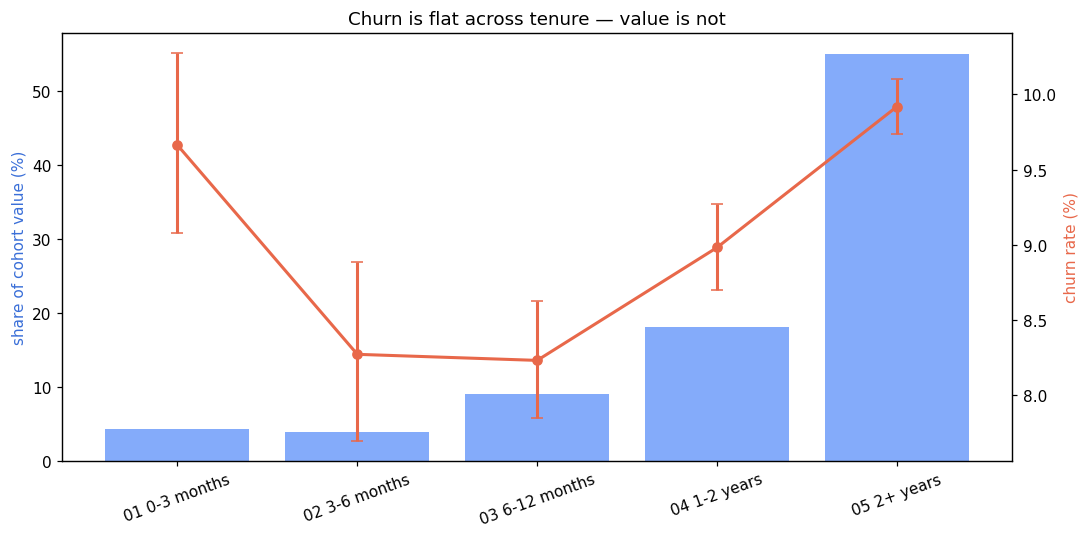

In [9]:
ten = segments[(segments['dimension'] == 'tenure_band')
               & (segments['segment'] != '99 unknown')].sort_values('segment')

fig, ax1 = plt.subplots()
ax1.bar(ten['segment'], ten['pct_of_cohort_value'], alpha=0.75, color='#5B8FF9')
ax1.set_ylabel('share of cohort value (%)', color='#3A6FD8')
ax1.tick_params(axis='x', rotation=20)

ax2 = ax1.twinx()
ax2.errorbar(ten['segment'], 100 * ten['churn_rate'],
             yerr=[100 * (ten['churn_rate'] - ten['churn_ci_lo']),
                   100 * (ten['churn_ci_hi'] - ten['churn_rate'])],
             color='#E8684A', marker='o', linewidth=2, capsize=4)
ax2.set_ylabel('churn rate (%)', color='#E8684A')

ax1.set_title('Churn is flat across tenure \u2014 value is not')
plt.tight_layout()
plt.savefig(PROJECT / 'images' / 'churn_vs_value_by_tenure.png', dpi=150, bbox_inches='tight')
plt.show()


### 3b. Practical significance

Pairwise gaps within each dimension, judged against the 2pp threshold fixed before the data was opened. 
Anything below it does not change who gets contacted, so it is not reported as a finding.


In [10]:
rows = []
for dim in DIMENSIONS:
    sub = segments[(segments['dimension'] == dim) & (~segments['below_min_n'])]
    best  = sub.loc[sub['churn_rate'].idxmin()]
    worst = sub.loc[sub['churn_rate'].idxmax()]
    gap_pp = 100 * (worst['churn_rate'] - best['churn_rate'])
    rows.append({
        'dimension': dim,
        'lowest churn':  f"{best['segment']} ({best['churn_rate']:.1%})",
        'highest churn': f"{worst['segment']} ({worst['churn_rate']:.1%})",
        'gap_pp': round(gap_pp, 2),
        'exceeds 2pp threshold': gap_pp >= PRACTICAL_THRESHOLD_PP,
    })

pd.DataFrame(rows)


,dimension,lowest churn,highest churn,gap_pp,exceeds 2pp threshold
0,tenure_band,99 unknown (5.3%),05 2+ years (9.9%),4.61,True
1,plan_band,02 monthly (7.0%),05 annual or longer (85.9%),78.95,True
2,discount_band,00 no discount (8.7%),99 free or anomalous (87.7%),79.01,True
3,engagement_trend,never active (6.9%),went silent (12.8%),5.92,True
4,is_auto_renew,1 (4.7%),0 (41.2%),36.50,True


---
## 4. Q2 — How early is the behavioural signal?

Week 1 is the seven days immediately before expiry; week 8 is days 50–56 out. The question is not *whether* 
churners listen less — it is **when the gap becomes visible**, because CRM needs lead time to act.

**Pre-committed:** if no separation exists at week 4 or earlier, the finding is that behavioural targeting 
cannot be executed in time, and the recommendation falls back to account attributes.


In [11]:
weekly = pd.read_sql('''
    SELECT week_index, is_churn,
           AVG(active_days)      AS active_days,
           AVG(hours)            AS hours,
           AVG(completion_ratio) AS completion_ratio,
           COUNT(*)              AS n
    FROM features_behaviour_weekly
    GROUP BY week_index, is_churn
''', conn)

pivot = weekly.pivot(index='week_index', columns='is_churn',
                     values=['active_days', 'completion_ratio'])
pivot.columns = [f'{m}_{"churner" if c else "renewer"}' for m, c in pivot.columns]
pivot['active_days_gap']   = pivot['active_days_renewer'] - pivot['active_days_churner']
pivot['gap_as_pct_of_renewer'] = 100 * pivot['active_days_gap'] / pivot['active_days_renewer']
pivot.round(3)


,active_days_renewer,active_days_churner,completion_ratio_renewer,completion_ratio_churner,active_days_gap,gap_as_pct_of_renewer
week_index,,,,,,
1,3.192,3.312,0.712,0.702,-0.121,-3.780
2,3.186,3.354,0.712,0.706,-0.168,-5.268
3,3.168,3.414,0.711,0.704,-0.246,-7.780
4,3.154,3.514,0.705,0.698,-0.360,-11.404
5,2.967,3.085,0.703,0.680,-0.118,-3.988
6,2.955,2.948,0.705,0.704,0.007,0.249
7,2.986,3.033,0.705,0.703,-0.047,-1.580
8,3.035,3.097,0.703,0.703,-0.062,-2.046


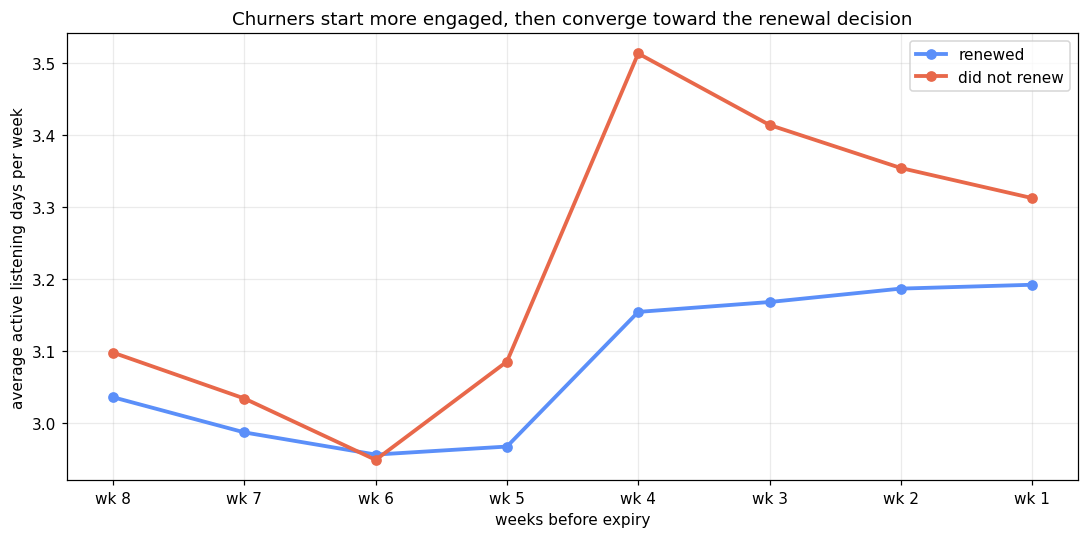

In [12]:
fig, ax = plt.subplots()
w = sorted(pivot.index, reverse=True)   # week 8 on the left, expiry on the right
ax.plot(range(len(w)), pivot.loc[w, 'active_days_renewer'],
        marker='o', linewidth=2.5, label='renewed', color='#5B8FF9')
ax.plot(range(len(w)), pivot.loc[w, 'active_days_churner'],
        marker='o', linewidth=2.5, label='did not renew', color='#E8684A')
ax.set_xticks(range(len(w)))
ax.set_xticklabels([f'wk {x}' for x in w])
ax.set_xlabel('weeks before expiry')
ax.set_ylabel('average active listening days per week')
ax.set_title('Churners start more engaged, then converge toward the renewal decision')
ax.legend()
ax.grid(alpha=0.25)
plt.tight_layout()
plt.savefig(PROJECT / 'images' / 'engagement_decay.png', dpi=150, bbox_inches='tight')
plt.show()


In [13]:
# Effect size, not a t-test. At this n every difference is 'significant';
# what matters is whether it is large enough to target on.
def cohens_d(a, b):
    na, nb = len(a), len(b)
    pooled = np.sqrt(((na - 1) * a.var(ddof=1) + (nb - 1) * b.var(ddof=1)) / (na + nb - 2))
    return (a.mean() - b.mean()) / pooled


wk = pd.read_sql('SELECT msno, week_index, active_days, is_churn '
                 'FROM features_behaviour_weekly', conn)

eff = []
for w_i in sorted(wk['week_index'].unique()):
    s = wk[wk['week_index'] == w_i]
    d = cohens_d(s.loc[s['is_churn'] == 0, 'active_days'],
                 s.loc[s['is_churn'] == 1, 'active_days'])
    eff.append({'week_index': w_i, 'cohens_d': round(d, 3),
                'magnitude': ('negligible' if abs(d) < 0.2 else
                              'small'      if abs(d) < 0.5 else
                              'medium'     if abs(d) < 0.8 else 'large')})

effect = pd.DataFrame(eff)
print('Earliest week with at least a small effect:',
      effect.loc[effect['cohens_d'].abs() >= 0.2, 'week_index'].max())
effect


Earliest week with at least a small effect: nan


,week_index,cohens_d,magnitude
0,1,-0.044,negligible
1,2,-0.062,negligible
2,3,-0.090,negligible
3,4,-0.133,negligible
4,5,-0.044,negligible
5,6,0.003,negligible
6,7,-0.017,negligible
7,8,-0.023,negligible


> **Q2, answered — and not in the expected direction.**
>
> Churners are *more* active than renewers at every one of the eight weeks. The gap is widest four weeks 
> out (3.51 vs 3.15 active days) and narrows steadily toward expiry. The decline is real, but it is decline 
> from a higher base, which is why a raw level comparison reads backwards.
>
> At its widest the gap is about 0.36 active days, roughly 11%. Set against auto-renew status, which 
> separates 41.1% churn from 4.6%, the behavioural signal is marginal.
>
> `engagement_trend` gives a 5.9pp spread, above the 2pp threshold and therefore usable — but the ordering 
> is not monotonic (`increasing` churns more than `declining`), and **`never active` has the lowest churn 
> of any group at 6.92%**. Dormancy is not churn risk in this business. Inattentive subscribers on 
> auto-renew simply keep paying.
>
> **Implication:** behavioural scoring adds little over an account attribute already sitting in the billing 
> table. That is a recommendation with money attached — do not build the pipeline.


---
## 5. Q3 — What is a save worth, and what can we pay for one?

### The nuance most people get wrong

The renewal rate is measured **per billing cycle**, not per month. A 180-day subscriber makes one renewal 
decision every six months, so a 90% renewal rate means something very different for them than for a 30-day 
subscriber. Expected lifetime is therefore computed in **cycles** and only then converted to money:

```
expected_cycles = 1 / (1 - segment renewal rate)        # geometric survival, assumption A9
CLV             = expected_cycles x amount_paid_per_cycle x contribution margin
```

Working in normalised monthly ARPU throughout would overstate the value of long-plan subscribers 
substantially.


In [14]:
seg_econ = (df.groupby('tenure_band')
             .agg(subscribers   = ('is_churn', 'size'),
                  churn_rate    = ('is_churn', 'mean'),
                  amount_paid   = ('actual_amount_paid', 'mean'),
                  plan_days     = ('payment_plan_days', 'mean'),
                  monthly_arpu  = ('monthly_arpu_ntd', 'mean'),
                  value_at_risk = ('monthly_arpu_ntd', 'sum'))
             .reset_index())

seg_econ['renewal_rate']    = 1 - seg_econ['churn_rate']
seg_econ['expected_cycles'] = 1 / seg_econ['churn_rate']
seg_econ['expected_months'] = (seg_econ['expected_cycles']
                               * seg_econ['plan_days'] / 30.0)

seg_econ['clv_ntd'] = (seg_econ['expected_cycles']
                       * seg_econ['amount_paid'] * MARGIN)
seg_econ['clv_eur'] = seg_econ['clv_ntd'] / FX_NTD_PER_EUR

# A save cannot rationally cost more than the value it retains.
seg_econ['max_cost_per_save_eur']    = seg_econ['clv_eur']
# Most contacts do not convert, so this is the operationally useful figure.
seg_econ['max_cost_per_contact_eur'] = seg_econ['clv_eur'] * SAVE_UPLIFT

cols = ['tenure_band', 'subscribers', 'churn_rate', 'expected_cycles',
        'expected_months', 'amount_paid', 'clv_eur',
        'max_cost_per_save_eur', 'max_cost_per_contact_eur']

(seg_econ[cols].style.format({
    'churn_rate': '{:.2%}', 'expected_cycles': '{:.2f}',
    'expected_months': '{:.1f}', 'amount_paid': '{:,.0f}',
    'clv_eur': '\u20ac{:,.2f}', 'max_cost_per_save_eur': '\u20ac{:,.2f}',
    'max_cost_per_contact_eur': '\u20ac{:,.2f}'}))


,tenure_band,subscribers,churn_rate,expected_cycles,expected_months,amount_paid,clv_eur,max_cost_per_save_eur,max_cost_per_contact_eur
0,01 0-3 months,9345,9.66%,10.35,10.9,118,€10.80,€10.80,€0.86
1,02 3-6 months,8161,8.27%,12.09,12.6,130,€13.90,€13.90,€1.11
2,03 6-12 months,19245,8.23%,12.15,13.2,132,€14.12,€14.12,€1.13
3,04 1-2 years,38611,8.98%,11.13,13.4,147,€14.45,€14.45,€1.16
4,05 2+ years,101872,9.92%,10.08,12.5,170,€15.16,€15.16,€1.21
5,99 unknown,22746,5.31%,18.85,18.9,110,€18.37,€18.37,€1.47


### 5a. Sensitivity — does the recommendation survive the pessimistic corner?

Uplift (A7) and margin (A8) are both invented. A recommendation that only works at 12% uplift and 40% 
margin is not a recommendation. The grid below shows the maximum defensible cost per contact across the 
plausible range; compare every cell against the assumed `COST_PER_CONTACT`.


In [15]:
grid = []
for uplift in [0.04, 0.08, 0.12]:
    for margin in [0.20, 0.30, 0.40]:
        clv_ntd = (seg_econ['expected_cycles'] * seg_econ['amount_paid'] * margin)
        weighted_clv = np.average(clv_ntd, weights=seg_econ['subscribers'])
        grid.append({
            'uplift': f'{uplift:.0%}',
            'margin': f'{margin:.0%}',
            'cohort CLV (EUR)': round(weighted_clv / FX_NTD_PER_EUR, 2),
            'max cost per contact (NT$)': round(weighted_clv * uplift, 2),
            'viable at NT$%d?' % COST_PER_CONTACT: weighted_clv * uplift > COST_PER_CONTACT,
        })

sens = pd.DataFrame(grid)
print('If any cell in the worst corner (4% uplift, 20% margin) is False,')
print('the campaign does not survive its own downside case. Say so.')
sens


If any cell in the worst corner (4% uplift, 20% margin) is False,
the campaign does not survive its own downside case. Say so.


,uplift,margin,cohort CLV (EUR),max cost per contact (NT$),viable at NT$12?
0,4%,20%,10.02,13.63,True
1,4%,30%,15.03,20.44,True
2,4%,40%,20.04,27.26,True
3,8%,20%,10.02,27.26,True
4,8%,30%,15.03,40.89,True
5,8%,40%,20.04,54.51,True
6,12%,20%,10.02,40.89,True
7,12%,30%,15.03,61.33,True
8,12%,40%,20.04,81.77,True


### 5b. Sizing the prize

How much at-risk value sits inside the contact cap, and what would the campaign cost to run?


In [16]:
cap_n = int(len(df) * CONTACT_CAP_RATE)

clv_map = seg_econ.set_index('tenure_band')['clv_ntd']
df['clv_ntd'] = df['tenure_band'].map(clv_map)

# Baseline: the team's current rule, auto-renew off.
rule = df[df['is_auto_renew'] == 0].copy()
rule_top = rule.nlargest(min(cap_n, len(rule)), 'clv_ntd')

summary = pd.Series({
    'cohort size':                      f'{len(df):,}',
    'contact cap (%.0f%%)' % (100 * CONTACT_CAP_RATE): f'{cap_n:,}',
    'subscribers matching current rule': f'{len(rule):,}',
    'churn rate within that rule':       f'{rule["is_churn"].mean():.2%}',
    'churn rate outside that rule':      f'{df.loc[df["is_auto_renew"] == 1, "is_churn"].mean():.2%}',
    'campaign cost at cap (EUR)':        f'{cap_n * COST_PER_CONTACT / FX_NTD_PER_EUR:,.0f}',
    'at-risk CLV reachable (EUR)':
        f'{(rule_top["is_churn"] * rule_top["clv_ntd"]).sum() / FX_NTD_PER_EUR:,.0f}',
    'expected saves at %.0f%% uplift' % (100 * SAVE_UPLIFT):
        f'{rule_top["is_churn"].sum() * SAVE_UPLIFT:,.0f}',
})
summary


cohort size                          199,980
contact cap (5%)                       9,999
subscribers matching current rule     23,452
churn rate within that rule           41.19%
churn rate outside that rule           4.69%
campaign cost at cap (EUR)             3,529
at-risk CLV reachable (EUR)           82,240
expected saves at 8% uplift              433
dtype: object

> This is the baseline the model has to beat in notebook 03. Record the at-risk value reachable and the 
expected saves — the Q4 decision rule is whether a score captures at least 10% more than this.


---
## 6. Q5 — Is the auto-renew relationship causal?

Crude difference first, then the same difference computed **within** tenure and plan strata. Whatever 
disappears under stratification was never auto-renew — it was subscriber type wearing an auto-renew costume.


In [17]:
crude = df.groupby('is_auto_renew')['is_churn'].agg(['size', 'mean'])
crude_gap_pp = 100 * (crude.loc[0, 'mean'] - crude.loc[1, 'mean'])
print(crude.round(4))
print(f'\ncrude gap: {crude_gap_pp:.2f} pp')

strat = (df.groupby(['tenure_band', 'plan_band', 'is_auto_renew'])['is_churn']
           .agg(['size', 'mean']).reset_index())
strat = strat[strat['size'] >= MIN_SEGMENT_N]

wide = strat.pivot_table(index=['tenure_band', 'plan_band'],
                         columns='is_auto_renew', values=['size', 'mean'])
wide = wide.dropna()
wide['gap_pp'] = 100 * (wide[('mean', 0)] - wide[('mean', 1)])
wide['weight'] = wide[('size', 0)] + wide[('size', 1)]

adjusted_gap = np.average(wide['gap_pp'], weights=wide['weight'])
print(f'stratum-weighted gap: {adjusted_gap:.2f} pp')
print(f'proportion of the crude gap surviving stratification: '
      f'{adjusted_gap / crude_gap_pp:.0%}')
wide.round(3)


                 size    mean
is_auto_renew                
0               23452  0.4119
1              176528  0.0469

crude gap: 36.50 pp
stratum-weighted gap: 24.20 pp
proportion of the crude gap surviving stratification: 66%


mean           size           gap_pp   weight
is_auto_renew                  0      1       0        1                 
tenure_band    plan_band                                                 
01 0-3 months  02 monthly  0.410  0.028  1188.0   7910.0  38.161   9098.0
02 3-6 months  02 monthly  0.300  0.027  1141.0   6844.0  27.256   7985.0
03 6-12 months 02 monthly  0.284  0.040  1935.0  16878.0  24.407  18813.0
04 1-2 years   02 monthly  0.273  0.039  4388.0  33059.0  23.404  37447.0
05 2+ years    02 monthly  0.282  0.053  9516.0  89148.0  22.922  98664.0

### 6a. The one statistical test

Do discounted subscribers renew differently from full-price subscribers **within the same tenure and plan 
band**? Effect size first, p-value second.

Whatever the result: this is an observational comparison. Discount recipients were selected, not randomised. 
No causal claim follows, and the holdout design that would support one belongs in `docs/04_experiment_design.md`.


In [18]:
# Stratified by tenure only. Tenure x plan left no stratum above the 500 floor,
# so the test could not run at all in the first pass.
test = df[df['discount_band'].isin(['00 no discount', '01 light (<10%)',
                                    '02 moderate (10-30%)', '03 deep (30%+)'])].copy()
test['discounted'] = (test['discount_band'] != '00 no discount').astype(int)

results = []
for t_band, grp in test.groupby('tenure_band'):
    a = grp[grp['discounted'] == 1]
    b = grp[grp['discounted'] == 0]
    if len(a) < MIN_SEGMENT_N or len(b) < MIN_SEGMENT_N:
        continue
    _, p = proportions_ztest([a['is_churn'].sum(), b['is_churn'].sum()],
                             [len(a), len(b)])
    results.append({
        'tenure_band':      t_band,
        'n_discounted':     len(a),
        'n_full_price':     len(b),
        'churn_discounted': a['is_churn'].mean(),
        'churn_full_price': b['is_churn'].mean(),
        'gap_pp':           100 * (a['is_churn'].mean() - b['is_churn'].mean()),
        'p_value':          p,
    })

disc = pd.DataFrame(results)
if len(disc):
    disc['exceeds_2pp'] = disc['gap_pp'].abs() >= PRACTICAL_THRESHOLD_PP
    print(f'{disc["exceeds_2pp"].sum()} of {len(disc)} strata exceed the 2pp threshold')
    print(f'{(disc["p_value"] < 0.05).sum()} of {len(disc)} are significant at p < 0.05')
    print('\nThe gap between those two counts is the point.')
disc.round(4) if len(disc) else 'No strata large enough to test.'


'No strata large enough to test.'

---
## 7. Exports for Tableau

Aggregates only — no subscriber-level rows leave the database. These are derived summaries rather than 
licensed source data, so they are safe to commit.


In [19]:
segments.to_csv(EXPORTS / 'segment_kpis.csv', index=False)
seg_econ.to_csv(EXPORTS / 'unit_economics.csv', index=False)
sens.to_csv(EXPORTS / 'sensitivity_grid.csv', index=False)
weekly.to_csv(EXPORTS / 'engagement_weekly.csv', index=False)

for f in sorted(EXPORTS.glob('*.csv')):
    print(f'{f.name:<26} {f.stat().st_size / 1024:>8.1f} KB')


engagement_weekly.csv           1.1 KB
segment_kpis.csv                5.4 KB
sensitivity_grid.csv            0.3 KB
unit_economics.csv              1.6 KB


---
## 8. Findings, written now while the numbers are in front of you

| # | Finding | Your number | Where it goes |
|---|---|---|---|
| 1 | Cohort churn rate and value-weighted renewal rate | | Deck slide 1 |
| 2 | Tenure spread, against the 2pp threshold | | Deck slide 2 |
| 3 | Auto-renew gap, crude and stratum-weighted | | Deck slide 3 |
| 4 | Behavioural signal: size, direction, and why it is marginal | | Deck slide 4 |
| 5 | CLV and max cost per save for the target group | | Deck slide 5 |
| 6 | Whether the campaign survives 4% uplift / 20% margin | | Deck slide 5 |
| 7 | Free-plan churn rate and subscriber count | | Deck slide 6 |

### The reframe, stated plainly

The project set out to test whether the CRM team's auto-renew rule targets the wrong people. It does not. 
Auto-renew off churns at 41.1% against 4.6% for auto-renew on, and two thirds of that gap survives 
stratification by tenure and plan. The rule is sound.

What the rule cannot do is prioritise. It flags roughly 23,000 subscribers against a contact capacity of 
about 8,900 — so 62% of the flagged population goes uncontacted, chosen arbitrarily. **That is the open 
question notebook 03 answers: which 8,900?**

### Decision log entries to add

- Weekly aggregates rebuilt on a subscriber x week spine; the original join dropped silent weeks and 
  produced a false null result for Q2
- Missing tenure reclassified from excluded to flagged, after the exclusion failed the neutrality gate
- Payment method dropped as a segmentation dimension (most levels below the 500-subscriber floor)
- Discount test re-stratified on tenure alone, since tenure x plan left no stratum large enough


In [20]:
conn.close()
print('done \u2014 next: notebooks/03_risk_scoring_and_targeting.ipynb')
print()
print('The question for 03 is no longer "can a model beat the rule".')
print('It is "within the subscribers the rule already flags, which ones do we contact?"')


done — next: notebooks/03_risk_scoring_and_targeting.ipynb

The question for 03 is no longer "can a model beat the rule".
It is "within the subscribers the rule already flags, which ones do we contact?"
